# Multinomial Logistic Regression — Passenger Class

## Objective
Develop a Logistic Regression classification model to predict **`Pclass`** and evaluate it using standard classification metrics.

### Data assumption
The data is preprocessed once in Section 2 (duplicates removed, imputation, encoding and scaling fitted on the training data only):
- `X_train1` = 80% preprocessed features (target column removed)
- `X_test1` = 20% preprocessed features (target column removed)
- `y_train` = target for training
- `y_test` = target for testing

**No additional imputation, encoding, or scaling is performed after Section 2.**

### Required outputs
- `evaluate_classifier()` function
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Classification report
- Coefficient bar chart

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score
)

## 2. Load Data and Create the Preprocessed Train/Test Split

In [2]:
# ------------------------------------------------------------
# Load the raw CSV and rebuild the preprocessed 80/20 train-test data.
# (The processed train/test CSV files are not stored on disk, so the
#  same preprocessing steps are applied here once, before modelling.)
# Steps: drop duplicates -> split -> median-impute numeric (+ missing
# indicators) -> mode-impute + one-hot encode nominal -> standard-scale.
# ------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_PATH = r"C:\Users\dhruv\OneDrive\KLH Univeristy\4th semester (Trimester Format KLH)\25SC2107E Machine Learning\Placement Prediction System (OS-SEC-2(2026-27))\data\titanic.csv"

TARGET = "Pclass"
DROP_COLS = ['PassengerId', 'Name', 'Ticket', 'Cabin']          # identifier / free-text columns
ORDINAL_MAPS = {}        # ordered categories -> integers

df = pd.read_csv(DATA_PATH)
df = df.drop_duplicates().reset_index(drop=True)

X = df.drop(columns=[TARGET] + DROP_COLS)
y = df[TARGET]

for col, mapping in ORDINAL_MAPS.items():
    if col in X.columns:
        X[col] = X[col].map(mapping)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
nominal_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# ----- numeric: median imputation (fit on train only) + missing indicators -----
num_imputer = SimpleImputer(strategy="median")
X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[numeric_cols]),
                           columns=numeric_cols, index=X_train.index)
X_test_num = pd.DataFrame(num_imputer.transform(X_test[numeric_cols]),
                          columns=numeric_cols, index=X_test.index)

for col in [c for c in numeric_cols if X_train[c].isna().any()]:
    X_train_num[col + "_missing"] = X_train[col].isna().astype(int)
    X_test_num[col + "_missing"] = X_test[col].isna().astype(int)

# ----- nominal: most-frequent imputation + one-hot encoding (drop first) -----
parts_train, parts_test = [X_train_num], [X_test_num]
if nominal_cols:
    nom_imputer = SimpleImputer(strategy="most_frequent")
    X_train_nom = pd.DataFrame(nom_imputer.fit_transform(X_train[nominal_cols]),
                               columns=nominal_cols, index=X_train.index)
    X_test_nom = pd.DataFrame(nom_imputer.transform(X_test[nominal_cols]),
                              columns=nominal_cols, index=X_test.index)

    encoder = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)
    enc_train = encoder.fit_transform(X_train_nom)
    enc_names = encoder.get_feature_names_out(nominal_cols)
    parts_train.append(pd.DataFrame(enc_train, columns=enc_names, index=X_train.index))
    parts_test.append(pd.DataFrame(encoder.transform(X_test_nom), columns=enc_names, index=X_test.index))

X_train_processed = pd.concat(parts_train, axis=1)
X_test_processed = pd.concat(parts_test, axis=1)

# ----- scaling (fit on train only) -----
scaler = StandardScaler()
X_train_processed[numeric_cols] = scaler.fit_transform(X_train_processed[numeric_cols])
X_test_processed[numeric_cols] = scaler.transform(X_test_processed[numeric_cols])

print("Raw data shape      :", df.shape)
print("X_train_processed   :", X_train_processed.shape)
print("X_test_processed    :", X_test_processed.shape)

Raw data shape      : (891, 12)
X_train_processed   : (712, 9)
X_test_processed    : (179, 9)


In [3]:
X_train1 = X_train_processed
X_test1 = X_test_processed

print("X_train1:", X_train1.shape)
print("X_test1 :", X_test1.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

print("\nTarget distribution:")
print(y_train.value_counts().sort_index())

X_train1: (712, 9)
X_test1 : (179, 9)
y_train : (712,)
y_test  : (179,)

Target distribution:
Pclass
1    173
2    147
3    392
Name: count, dtype: int64


## 3. Verify Preprocessed Data

In [4]:
print("Missing values in X_train1:", X_train1.isna().sum().sum())
print("Missing values in X_test1 :", X_test1.isna().sum().sum())

print("\nFeature columns:")
print(list(X_train1.columns))

print("\nTarget classes:")
print(sorted(pd.Series(y_train).unique()))

Missing values in X_train1: 0
Missing values in X_test1 : 0

Feature columns:
['Survived', 'Age', 'SibSp', 'Parch', 'Fare', 'Age_missing', 'Sex_male', 'Embarked_Q', 'Embarked_S']

Target classes:
[np.int64(1), np.int64(2), np.int64(3)]


In [5]:
print("Categorical columns in X_train1:")
print(X_train1.select_dtypes(include="object").columns)

Categorical columns in X_train1:
Index([], dtype='str')


In [6]:
X_train1.columns

Index(['Survived', 'Age', 'SibSp', 'Parch', 'Fare', 'Age_missing', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='str')

## 4. Train Multinomial Logistic Regression

`Pclass` contains multiple classes, so multinomial Logistic Regression is used.

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

model.fit(X_train1, y_train)

print("Model trained successfully.")
print("Classes:", model.classes_)

Model trained successfully.
Classes: [1 2 3]


## 5. Define `evaluate_classifier()`

In [8]:
def evaluate_classifier(model, X, y, dataset_name="Dataset"):
    y_pred = model.predict(X)

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(
        y, y_pred, average="weighted", zero_division=0
    )
    recall = recall_score(
        y, y_pred, average="weighted", zero_division=0
    )
    f1 = f1_score(
        y, y_pred, average="weighted", zero_division=0
    )

    print(f"===== {dataset_name} =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y, y_pred, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y, y_pred))

    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision_weighted": precision,
        "Recall_weighted": recall,
        "F1_weighted": f1
    }

## 6. Evaluate Training and Test Performance

In [9]:
train_results = evaluate_classifier(
    model, X_train1, y_train, "Training"
)

test_results = evaluate_classifier(
    model, X_test1, y_test, "Test"
)

evaluation_df = pd.DataFrame([
    train_results,
    test_results
])

display(evaluation_df)

===== Training =====
Accuracy : 0.8301
Precision: 0.8272
Recall   : 0.8301
F1-score : 0.8077

Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.92      0.91       173
           2       0.79      0.35      0.49       147
           3       0.81      0.97      0.88       392

    accuracy                           0.83       712
   macro avg       0.83      0.75      0.76       712
weighted avg       0.83      0.83      0.81       712

Confusion Matrix:
[[160   8   5]
 [ 10  52  85]
 [  7   6 379]]
===== Test =====
Accuracy : 0.8324
Precision: 0.8443
Recall   : 0.8324
F1-score : 0.8145

Classification Report:
              precision    recall  f1-score   support

           1       0.93      0.86      0.89        43
           2       0.88      0.41      0.56        37
           3       0.80      0.98      0.88        99

    accuracy                           0.83       179
   macro avg       0.87      0.75      0.77       179

,Dataset,Accuracy,Precision_weighted,Recall_weighted,F1_weighted
0,Training,0.830056,0.827217,0.830056,0.807657
1,Test,0.832402,0.844331,0.832402,0.814513


## 7. Test Confusion Matrix

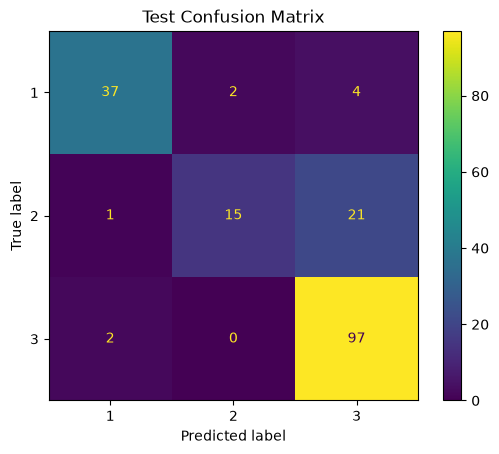

In [10]:
y_test_pred = model.predict(X_test1)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    values_format="d"
)

plt.title("Test Confusion Matrix")
plt.show()

## 8. Coefficients

In [11]:
# Binary: one coefficient per feature.
# Multinomial: one coefficient row per class.

if model.coef_.shape[0] == 1:
    coefficient_df = pd.DataFrame({
        "Feature": X_train1.columns,
        "Coefficient": model.coef_[0]
    })
    display(coefficient_df)

else:
    coefficient_df = pd.DataFrame(
        model.coef_,
        index=[f"Class={c}" for c in model.classes_],
        columns=X_train1.columns
    )
    display(coefficient_df)

,Survived,Age,SibSp,Parch,Fare,Age_missing,Sex_male,Embarked_Q,Embarked_S
Class=1,0.434644,0.645974,-0.955452,-0.420479,4.014365,0.423888,0.333776,-0.899538,-0.611562
Class=2,-0.037312,-0.151431,0.127762,-0.009536,0.188678,-0.736425,-0.345803,-0.050867,0.652406
Class=3,-0.397331,-0.494543,0.827690,0.430015,-4.203042,0.312538,0.012027,0.950405,-0.040843


## 9. Coefficient Bar Chart

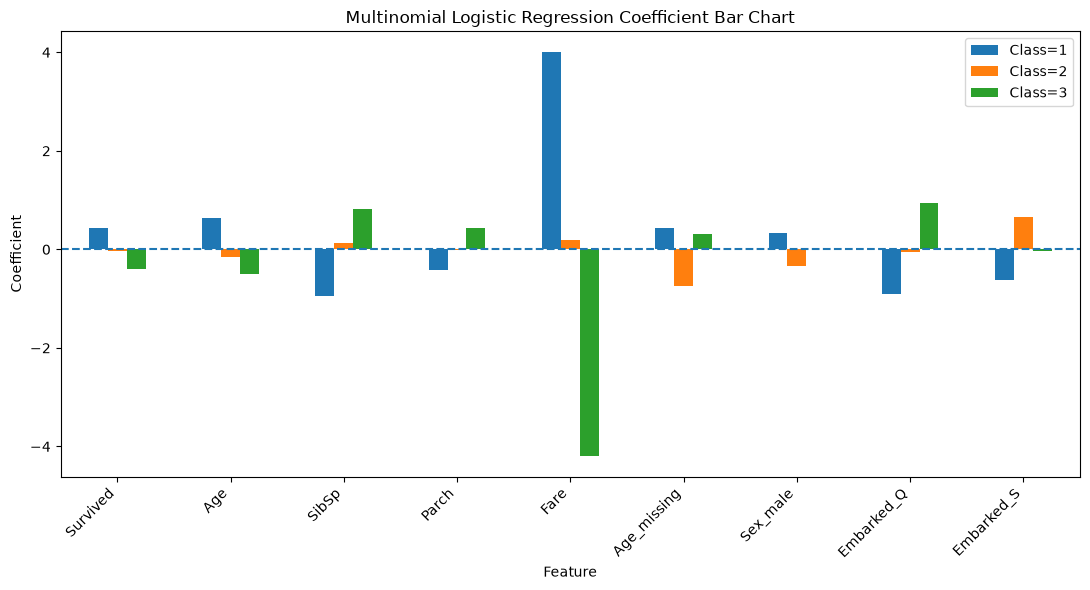

In [12]:
if model.coef_.shape[0] == 1:

    plot_df = pd.DataFrame({
        "Feature": X_train1.columns,
        "Coefficient": model.coef_[0]
    }).sort_values("Coefficient")

    plt.figure(figsize=(9, 6))
    plt.barh(plot_df["Feature"], plot_df["Coefficient"])
    plt.axvline(0, linestyle="--")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title("Logistic Regression Coefficient Bar Chart")
    plt.tight_layout()
    plt.show()

else:
    coefficient_plot_df = coefficient_df.T

    ax = coefficient_plot_df.plot(
        kind="bar",
        figsize=(11, 6)
    )

    ax.axhline(0, linestyle="--")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Coefficient")
    ax.set_title("Multinomial Logistic Regression Coefficient Bar Chart")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Interpretation and Conclusion

### Target
This notebook predicts **`Pclass`**.

### Metrics
- Accuracy: overall percentage of correct predictions.
- Precision: correctness of positive predictions.
- Recall: ability to identify actual positive cases.
- F1-score: balance between precision and recall.
- ROC-AUC: used for the binary model to measure discrimination across thresholds.

### Coefficients
A positive coefficient increases the model's tendency toward the corresponding class; a negative coefficient decreases it, subject to the preprocessing and class formulation.

### Final evaluation
The **test-set metrics** are the final performance results because `X_test1` and `y_test` are kept separate from model fitting.